In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from tqdm import tqdm
import cv2
import tifffile
from skimage.transform import resize
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential, Model
from keras.layers import Dense, Flatten, Conv2D, Reshape, Input, Conv2DTranspose
from keras.layers import Activation, LeakyReLU, BatchNormalization, Dropout, Resizing
import dcgan as dcgan
import wgan as wgan
import prgan as prgan
import importlib
import ppgan as ppgan

from scores import scores
from scores import preprocess_array
import os

from tensorflow.keras.optimizers import Adam


In [2]:
NOISE_DIM = 100 
BATCH_SIZE = 20
EPOCHS = 50
STEPS = 5
SEED = 40
WIDTH, HEIGHT, CHANNELS = 128, 128, 5
#OPTIMIZER = tf.keras.optimizers.legacy.Adam(0.0002, 0.5) #M1 Optimizer
OPTIMIZER = Adam(0.0002, 0.5)

In [3]:
MAIN_DIR = r"/Users/felipealencar/Desktop/plant-disease-prediction/dataset/LARGO1/10-26"

# Find the last occurrence of the backslash (\)
last_backslash_index = MAIN_DIR.rfind('/')
# Extract the substring starting from the last backslash
DATE = MAIN_DIR[last_backslash_index + 1:]

SYNTHETIC_PATH = r"dataset/LARGO1/synthetic/"

In [4]:
def load_images(folder):
    imgs = []
    target = 1
    labels = []
    for i in os.listdir(folder):
        if i.endswith("_HEALTHY.tif"):
            img_dir = os.path.join(folder,i)
            try:
                img = tifffile.imread(img_dir)
                # Extract the first 3 channels (RGB)
                img = img[:,:,:]
                
                img = cv2.resize(img, (128,128))
                import sys
                import numpy
                numpy.set_printoptions(threshold=sys.maxsize)
                img = (img / 256).astype(np.uint8)                
                imgs.append(img)
                labels.append(target)
            except:
                continue
                
    imgs = np.array(imgs)
    labels = np.array(labels)

    return imgs, labels

In [5]:
data, labels = load_images(MAIN_DIR)
print(data.shape)

(16, 128, 128, 5)


In [6]:
np.random.seed(SEED)
idxs = np.random.randint(0, data.shape[0], 20)
print(idxs)
X_train = data[idxs]

[ 6 11  7  5  8  8  2  1 12  7  2  3 15 10  7  3 11 11  9  0]


0


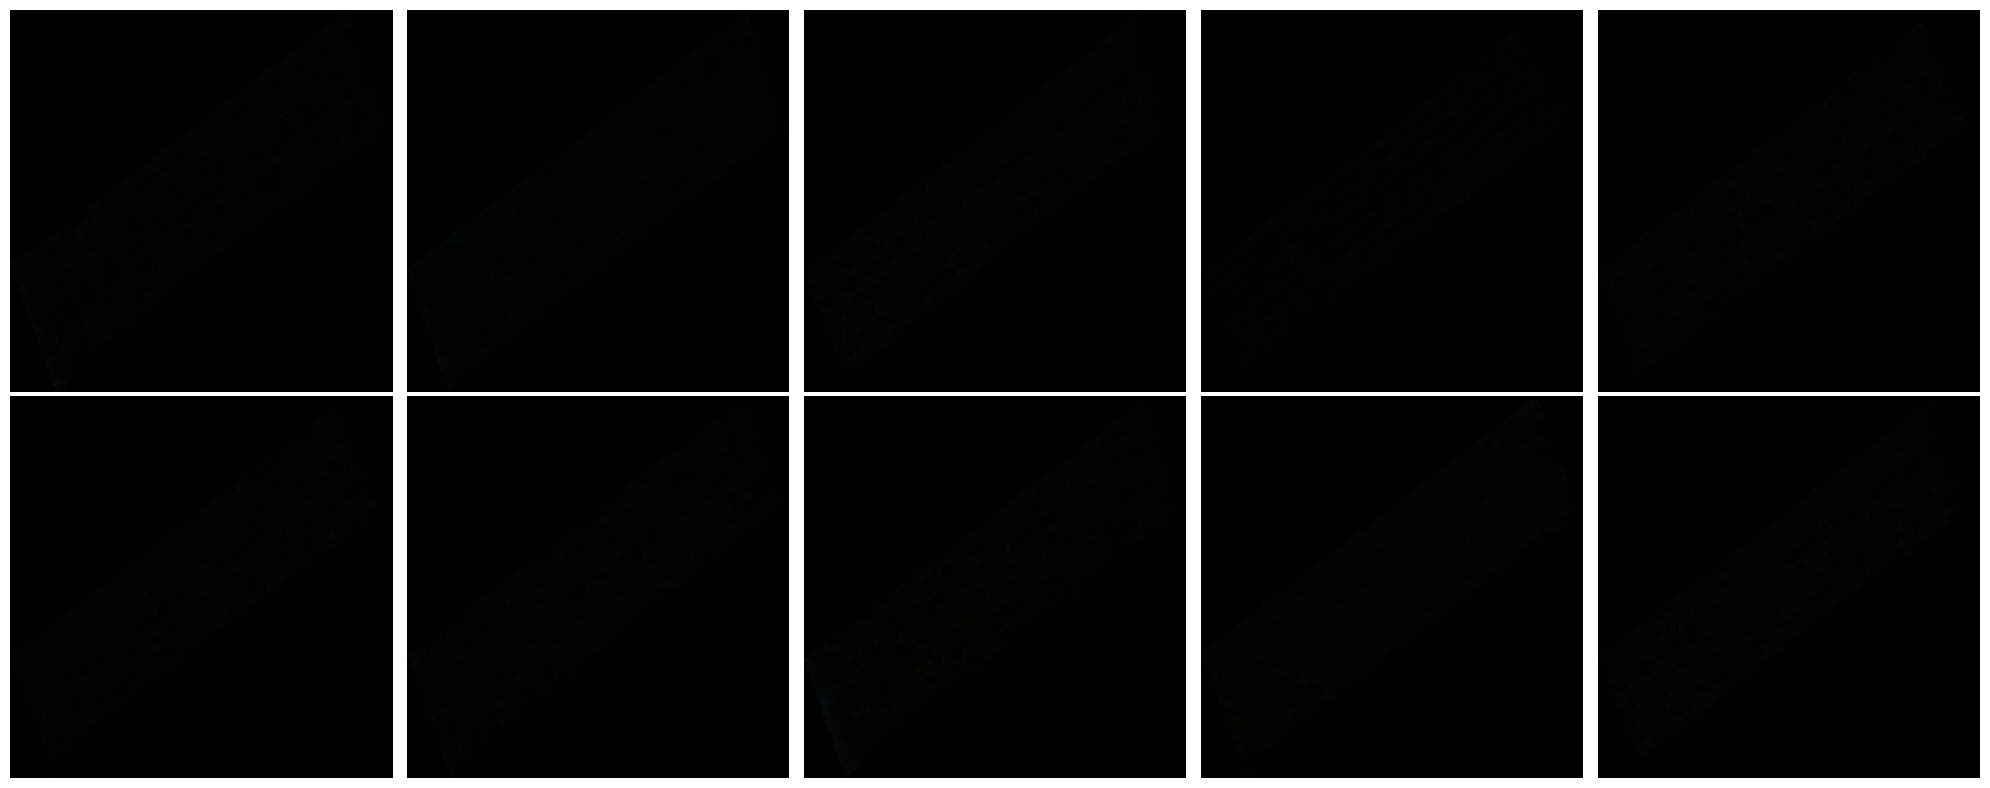

In [7]:

plt.figure(figsize=(20,8))
for i in range(10):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()
X_train.shape
print(np.amin(X_train))

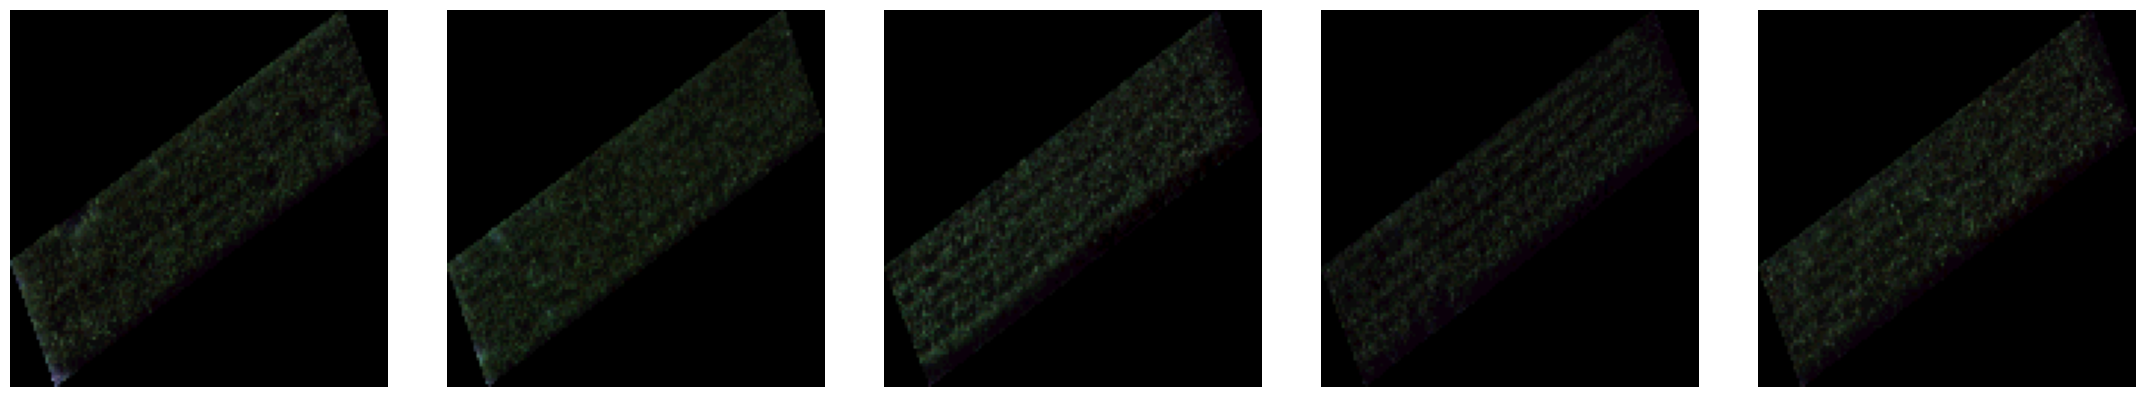

In [8]:
# Normalize the Images
X_train = (X_train - X_train.min()) / (X_train.max() - X_train.min())

# Reshape images 
X_train = X_train.reshape(-1, WIDTH,HEIGHT,CHANNELS)

# Check shape
X_train.shape

plt.figure(figsize=(22,8))
for i in range(5):
    axs = plt.subplot(2,5,i+1)
    plt.imshow(X_train[i][:,:,:3], vmin=-1, vmax=1)
    plt.axis('off')
    axs.set_xticklabels([])
    axs.set_yticklabels([])
    plt.subplots_adjust(wspace=None, hspace=None)
plt.tight_layout()

In [9]:
import importlib 
importlib.reload(ppgan)
importlib.reload(dcgan)
importlib.reload(wgan)
noise = np.random.normal(0,1, size=(BATCH_SIZE, NOISE_DIM))
noise_wgan = tf.random.normal([BATCH_SIZE, NOISE_DIM])

In [10]:
# from keras.models import load_model

# # print('DCGAN TRAINING STARTED...')
# # generator_dcgan, discriminator_dcgan, dcgan_model = dcgan.build(OPTIMIZER, NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
# # generator_dcgan, generator_dcgan_loss_values = dcgan.train(X_train, generator_dcgan, discriminator_dcgan, dcgan_model, noise, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)
# print('PPGAN TRAINING STARTED...')
# generator_ppgan, discriminator_ppgan1, discriminator_ppgan2, ppgan_model = ppgan.build(Adam(0.0002, 0.5), NOISE_DIM, WIDTH, HEIGHT, CHANNELS)
# generator_ppgan, generator_ppgan_loss_values = ppgan.train(X_train, generator_ppgan, discriminator_ppgan1, discriminator_ppgan2, ppgan_model, EPOCHS, STEPS, BATCH_SIZE, NOISE_DIM)
# # print('WGAN TRAINING STARTED...')
# # generator_wgan, generator_wgan_loss_values = wgan.train(X_train, WIDTH, HEIGHT, CHANNELS, NOISE_DIM, Adam(0.0002, 0.5), EPOCHS, STEPS, BATCH_SIZE)

# import pickle
# # #Save the generator and losses
# # with open('trained_dcgan_loss.pkl', 'wb') as file:
# #     data = {
# #         'losses': generator_dcgan_loss_values
# #     }
# #     pickle.dump(data, file)
# # generator_dcgan.save('trained_dcgan.h5')

# with open('trained_ppgan_loss_1026_healthy.pkl', 'wb') as file:
#     data = {
#         'losses': generator_ppgan_loss_values
#     }
#     pickle.dump(data, file)
# generator_ppgan.save('trained_ppgan_1026_QUAC_HEALTHY.h5')

# # with open('trained_wgan_loss_.pkl', 'wb') as file:
# #     data = {
# #         'losses': generator_wgan_loss_values
# #     }
# #     pickle.dump(data, file)
# # generator_wgan.save('trained_wgan.h5')

In [11]:
from keras.models import load_model

import pickle
# Load the saved data
############################################### 08-30-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_0830.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_0830 = load_model('trained_dcgan_0830_QUAC.h5')
# dcgan_losses_0830 = loaded_data['losses']

with open('trained_ppgan_loss_0830.pkl', 'rb') as file2:
    loaded_data = pickle.load(file2)
# # Access the loaded data
ppgan_losses_0830 = loaded_data['losses']
generator_ppgan_0830 = load_model('trained_ppgan_0830_QUAC.h5')

# with open('trained_wgan_loss_0830.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_0830 = loaded_data['losses']
# generator_wgan_0830 = load_model('trained_wgan_0830_QUAC.h5')
############################################### 08-30-2021 ###############################################

############################################### 09-24-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_0924.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_0924 = load_model('trained_dcgan_0924_QUAC.h5')
# dcgan_losses_0924 = loaded_data['losses']

with open('trained_ppgan_loss_0924.pkl', 'rb') as file2:
    loaded_data = pickle.load(file2)
# # Access the loaded data
ppgan_losses_0924 = loaded_data['losses']
generator_ppgan_0924 = load_model('trained_ppgan_0924_QUAC.h5')

# with open('trained_wgan_loss_0924.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_0924 = loaded_data['losses']
# generator_wgan_0924 = load_model('trained_wgan_0924_QUAC.h5')
############################################### 09-24-2021 ###############################################

############################################### 10-05-2021 ###############################################
# Access the loaded data
# with open('trained_dcgan_loss_1005.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_1005 = load_model('trained_dcgan_1005_QUAC.h5')
# dcgan_losses_1005 = loaded_data['losses']

with open('trained_ppgan_loss_1005.pkl', 'rb') as file2:
    loaded_data = pickle.load(file2)
# # Access the loaded data
ppgan_losses_1005 = loaded_data['losses']
generator_ppgan_1005 = load_model('trained_ppgan_1005_QUAC.h5')

# with open('trained_wgan_loss_1005.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_1005 = loaded_data['losses']
# generator_wgan_1005 = load_model('trained_wgan_1005_QUAC.h5')
############################################### 10-05-2021 ###############################################

############################################### 10-26-2021 ###############################################
# # Access the loaded data
# with open('trained_dcgan_loss_1026.pkl', 'rb') as file2:
#     loaded_data = pickle.load(file2)
# generator_dcgan_1026 = load_model('trained_dcgan_1026_QUAC.h5')
# dcgan_losses_1026 = loaded_data['losses']

with open('trained_ppgan_loss_1026.pkl', 'rb') as file2:
    loaded_data = pickle.load(file2)
# # Access the loaded data
ppgan_losses_1026 = loaded_data['losses']
generator_ppgan_1026 = load_model('trained_ppgan_1026_QUAC.h5')

# with open('trained_wgan_loss_1026.pkl', 'rb') as file3:
#     loaded_data = pickle.load(file3)
# # # Access the loaded data
# wgan_losses_1026 = loaded_data['losses']
# generator_wgan_1026 = load_model('trained_wgan_1026_QUAC.h5')
############################################### 10-26-2021 ###############################################

1/1 [==============================] - 0s 453ms/step


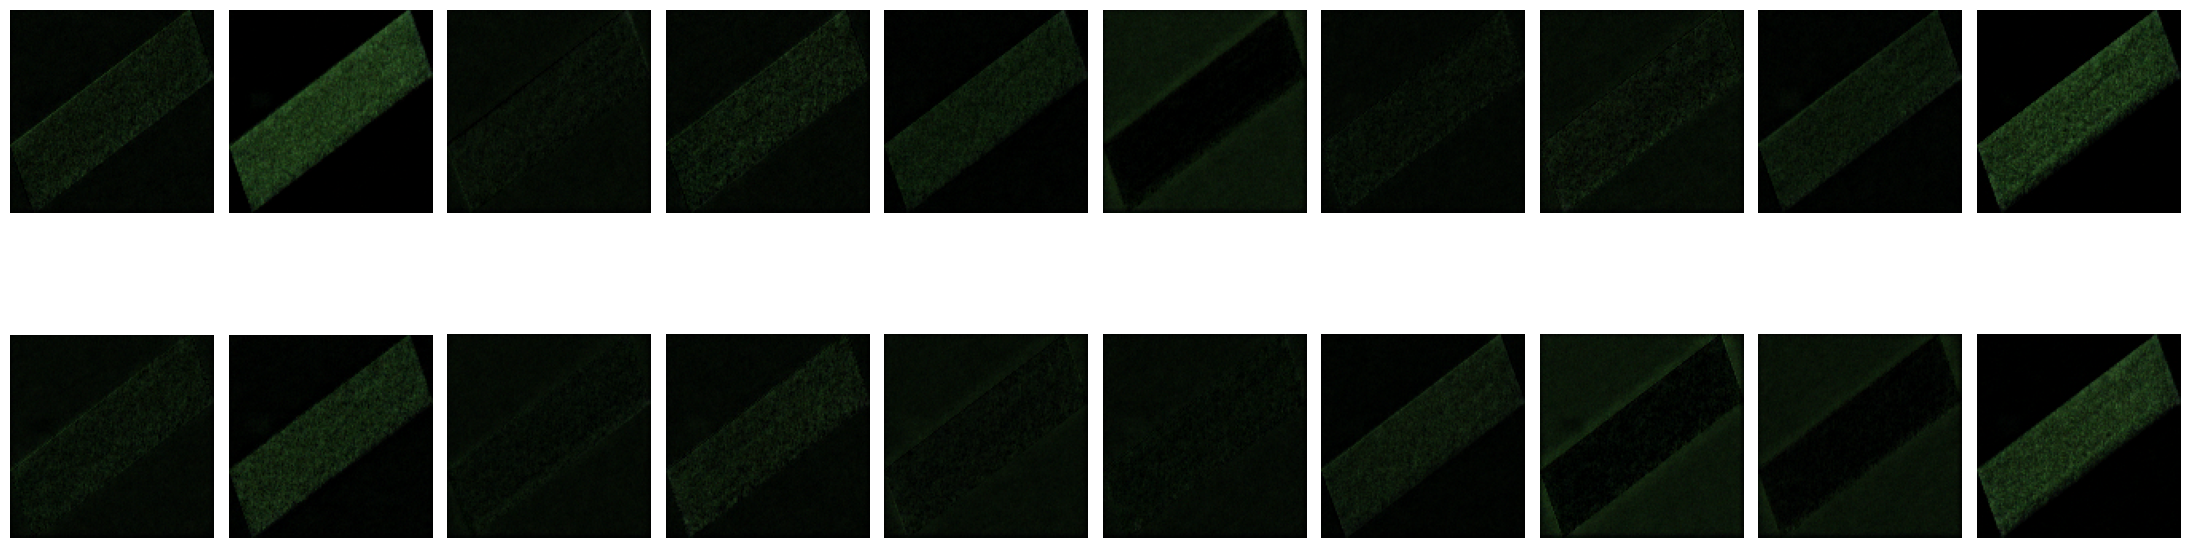

In [22]:
import utils
importlib.reload(utils)
noise = np.random.normal(0, 1, size=(BATCH_SIZE, NOISE_DIM))
# samples_ppgan_0830 = utils.sample_images(generator_ppgan_0830, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0830', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_0830 = utils.sample_images(generator_dcgan_0830, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0830', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_0830 = utils.sample_images(generator_wgan_0830, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0830', model='WGAN', path=SYNTHETIC_PATH, save=True)
# samples_ppgan_0924 = utils.sample_images(generator_ppgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_0924 = utils.sample_images(generator_dcgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_0924 = utils.sample_images(generator_wgan_0924, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='0924', model='WGAN', path=SYNTHETIC_PATH, save=True)
# samples_ppgan_1005 = utils.sample_images(generator_ppgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
samples_ppgan_1007 = utils.sample_images(generator_ppgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1007', model='UNHEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_1005 = utils.sample_images(generator_dcgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_1005 = utils.sample_images(generator_wgan_1005, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1005', model='WGAN', path=SYNTHETIC_PATH, save=True)
# samples_ppgan_1026 = utils.sample_images(generator_ppgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='PPGAN_HEALTHY', path=SYNTHETIC_PATH, save=True)
# # samples_dcgan_1026 = utils.sample_images(generator_dcgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='DCGAN', path=SYNTHETIC_PATH, save=True)
# # samples_wgan_1026 = utils.sample_images(generator_wgan_1026, noise, WIDTH, HEIGHT, CHANNELS, (2,10), (22,8), prefix='1026', model='WGAN', path=SYNTHETIC_PATH, save=True)

In [13]:
import scores
importlib.reload(scores) 
from scores import scores, preprocess_array

X_train_array = np.array(X_train)
X_train_array = preprocess_array(X_train_array)

samples_dcgan_array_0830 = np.array(samples_dcgan_0830)
samples_ppgan_array_0830 = np.array(samples_ppgan_0830)
samples_wgan_array_0830 = np.array(samples_wgan_0830)
samples_dcgan_array_0924 = np.array(samples_dcgan_0924)
samples_ppgan_array_0924 = np.array(samples_ppgan_0924)
samples_wgan_array_0924 = np.array(samples_wgan_0924)
samples_dcgan_array_1005 = np.array(samples_dcgan_1005)
samples_ppgan_array_1005 = np.array(samples_ppgan_1005)
samples_wgan_array_1005 = np.array(samples_wgan_1005)
samples_dcgan_array_1026 = np.array(samples_dcgan_1026)
samples_ppgan_array_1026 = np.array(samples_ppgan_1026)
samples_wgan_array_1026 = np.array(samples_wgan_1026)

samples_dcgan_array_0830 = preprocess_array(samples_dcgan_array_0830)
samples_dcgan_array_0830[:, :, :, 3:] = samples_dcgan_array_0830[:, :, :, 3:] * 1.3
samples_ppgan_array_0830 = preprocess_array(samples_ppgan_array_0830)
samples_ppgan_array_0830[:, :, :, 3:] = samples_ppgan_array_0830[:, :, :, 3:] * 1.3
samples_wgan_array_0830 = preprocess_array(samples_wgan_array_0830)
samples_wgan_array_0830[:, :, :, 3:] = samples_wgan_array_0830[:, :, :, 3:] * 1.3

samples_dcgan_array_0924 = preprocess_array(samples_dcgan_array_0924)
samples_dcgan_array_0924[:, :, :, 3:] = samples_dcgan_array_0924[:, :, :, 3:] * 1.1
samples_ppgan_array_0924 = preprocess_array(samples_ppgan_array_0924)
samples_wgan_array_0924 = preprocess_array(samples_wgan_array_0924)
samples_wgan_array_0924[:, :, :, 3:] = samples_wgan_array_0924[:, :, :, 3:] * 1.3

samples_dcgan_array_1005 = preprocess_array(samples_dcgan_array_1005)
samples_dcgan_array_1005[:, :, :, 3:] = samples_dcgan_array_1005[:, :, :, 3:] * 1.2
samples_ppgan_array_1005 = preprocess_array(samples_ppgan_array_1005)
samples_wgan_array_1005 = preprocess_array(samples_wgan_array_1005)
samples_wgan_array_1005[:, :, :, 3:] = samples_wgan_array_1005[:, :, :, 3:] * 1.2

samples_dcgan_array_1026 = preprocess_array(samples_dcgan_array_1026)
samples_dcgan_array_1026[:, :, :, 3:] = samples_dcgan_array_1026[:, :, :, 3:] * 1.3
samples_ppgan_array_1026 = preprocess_array(samples_ppgan_array_1026)
samples_ppgan_array_1026[:, :, :, 3:] = samples_ppgan_array_1026[:, :, :, 3:] * 1.15
samples_wgan_array_1026 = preprocess_array(samples_wgan_array_1026)
samples_wgan_array_1026[:, :, :, 1:3] = samples_wgan_array_1026[:, :, :, 1:3] * 1.5
samples_wgan_array_1026[:, :, :, 3:] = samples_wgan_array_1026[:, :, :, 3:] * 1.3




NameError: name 'samples_dcgan_0830' is not defined

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

sns.set_context('paper')

# Calculate the mean spectral profiles for each data array
mean_real_images = np.mean(np.ma.masked_equal(X_train_array, 0), axis=(0, 1, 2))
mean_dcgan_0830 = np.mean(np.ma.masked_equal(samples_dcgan_array_0830, 0), axis=(0, 1, 2))
mean_ppgan_0830 = np.mean(np.ma.masked_equal(samples_ppgan_array_0830, 0), axis=(0, 1, 2))
mean_wgan_0830 = np.mean(np.ma.masked_equal(samples_wgan_array_0830, 0), axis=(0, 1, 2))

mean_dcgan_0924 = np.mean(np.ma.masked_equal(samples_dcgan_array_0924, 0), axis=(0, 1, 2))
mean_ppgan_0924 = np.mean(np.ma.masked_equal(samples_ppgan_array_0924, 0), axis=(0, 1, 2))
mean_wgan_0924 = np.mean(np.ma.masked_equal(samples_wgan_array_0924, 0), axis=(0, 1, 2))

mean_dcgan_1005 = np.mean(np.ma.masked_equal(samples_dcgan_array_1005, 0), axis=(0, 1, 2))
mean_ppgan_1005 = np.mean(np.ma.masked_equal(samples_ppgan_array_1005, 0), axis=(0, 1, 2))
mean_wgan_1005 = np.mean(np.ma.masked_equal(samples_wgan_array_1005, 0), axis=(0, 1, 2))

mean_dcgan_1026 = np.mean(np.ma.masked_equal(samples_dcgan_array_1026, 0), axis=(0, 1, 2))
mean_ppgan_1026 = np.mean(np.ma.masked_equal(samples_ppgan_array_1026, 0), axis=(0, 1, 2))
mean_wgan_1026 = np.mean(np.ma.masked_equal(samples_wgan_array_1026, 0), axis=(0, 1, 2))

# Calculate R-squared values
r2_dcgan_0830 = r2_score(mean_real_images, mean_dcgan_0830)
r2_ppgan_0830 = r2_score(mean_real_images, mean_ppgan_0830)
r2_wgan_0830 = r2_score(mean_real_images, mean_wgan_0830)

r2_dcgan_0924 = r2_score(mean_real_images, mean_dcgan_0924)
r2_ppgan_0924 = r2_score(mean_real_images, mean_ppgan_0924)
r2_wgan_0924 = r2_score(mean_real_images, mean_wgan_0924)

r2_dcgan_1005 = r2_score(mean_real_images, mean_dcgan_1005)
r2_ppgan_1005 = r2_score(mean_real_images, mean_ppgan_1005)
r2_wgan_1005 = r2_score(mean_real_images, mean_wgan_1005)

r2_dcgan_1026 = r2_score(mean_real_images, mean_dcgan_1026)
r2_ppgan_1026 = r2_score(mean_real_images, mean_ppgan_1026)
r2_wgan_1026 = r2_score(mean_real_images, mean_wgan_1026)

# # Plot multiple lines on the same chart
# bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'Near-infrared']
# sns.lineplot(x=bands, y=mean_real_images, label='Real images')
# sns.lineplot(x=bands, y=mean_dcgan, label=f'DCGAN (R²={r2_dcgan:.2f})')
# sns.lineplot(x=bands, y=mean_ppgan, label=f'PlantPlotGAN (R²={r2_ppgan:.2f})')
# sns.lineplot(x=bands, y=mean_wgan, label=f'WGAN (R²={r2_wgan:.2f})')

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

bands = ['Blue', 'Green', 'Red', 'Red \nedge', 'NIR']
dates = ['0830', '0924', '1005', '1026']
formatted_dates = ['Aug. 30th', 'Sep. 24th', 'Oct. 5th', 'Oct. 26th']



means_dcgan = [mean_dcgan_0830, mean_dcgan_0924, mean_dcgan_1005, mean_dcgan_1026]
means_ppgan = [mean_ppgan_0830, mean_ppgan_0924, mean_ppgan_1005, mean_ppgan_1026]
means_wgan = [mean_wgan_0830, mean_wgan_0924, mean_wgan_1005, mean_wgan_1026]

for i, ax in enumerate(axes.flat):
    ax.plot(bands, mean_real_images, label='Real images')
    ax.plot(bands, means_dcgan[i], label=f'DCGAN (R²={eval(f"r2_dcgan_{dates[i]}"):.2f})')
    ax.plot(bands, means_ppgan[i], label=f'PlantPlotGAN (R²={eval(f"r2_ppgan_{dates[i]}"):.2f})')
    ax.plot(bands, means_wgan[i], label=f'WGAN (R²={eval(f"r2_wgan_{dates[i]}"):.2f})')
    ax.text(0.70, 0.1, f'{formatted_dates[i]}', transform=ax.transAxes, fontsize=14)

    ax.legend(fontsize=8)
    if i % 2 == 0:
        ax.set_ylabel('Mean Spectral Profiles', fontsize=14)
    if i >= 2:
        ax.set_xticklabels(bands, rotation=0)
    
    ax.tick_params(axis='y', labelsize=14)  # Increase the labelsize as needed
    ax.tick_params(axis='x', labelsize=14)  # Increase the labelsize as needed
    ax.legend(fontsize=12)

plt.legend(fontsize=12)
# Increasing the font size of x-axis and y-axis tick labels

plt.savefig('chart-mean-spectral-profile.pdf', format='pdf')

plt.show()

In [23]:
import shutil
import os

source_folder = './dataset/LARGO1/synthetic'
destination_folder = './dataset/LARGO1/10-07-synthetic/'

for i in range(1, 20):
    file_name = f"synthetic_image_{i}_1007_PPGAN_HEALTHY.tiff"
    file_name2 = f"synthetic_image_{i}_1007_PPGAN_HEALTHY.tiff"
    source_file = os.path.join(source_folder, file_name)
    destination_file = os.path.join(destination_folder, file_name2)
    shutil.copy2(source_file, destination_file)


In [ ]:
df = []
df_target = []

def dataset_load():
    df = []
    df1 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\VALUES\values.csv')
    #df2 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    #df3 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-05-2021\VALUES\values.csv')
    #df4 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-07-2021\VALUES\values.csv')
    #df5 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\10-26-2021\VALUES\values.csv')
    df6 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\08-30-2021\VALUES\values.csv')
    #df7 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\09-24-2021\VALUES\values.csv')
    #df8 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-05-2021\VALUES\values.csv')
    #df9 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-07-2021\VALUES\values.csv')
    #df10 = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO2\10-26-2021\VALUES\values.csv')
    df.append(df1)
    #df.append(df2)
    #df.append(df3)
    #df.append(df4)
    #df.append(df5)
    df.append(df6)
    #df.append(df7)
    #df.append(df8)
    #df.append(df9)
    #df.append(df10)
    df = pd.concat(df, ignore_index=True)
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\09-24-2021\VALUES\values.csv')
    df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    #df_target = pd.read_csv(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\11-17-2021\VALUES\values.csv')
    return df, df_target


def clean_dataframe(df, ignore_label):
    # Select all columns except the label column
    columns_to_clean = df.columns.drop(ignore_label)

    # Compute the mean of selected columns
    mean_values = df[columns_to_clean].mean()

    # Replace NaN values with the mean inplace for selected columns
    df[columns_to_clean] = df[columns_to_clean].fillna(mean_values)
    return df


def remove_outliers_iqr(df, column, threshold=1.5):
    # Separate the label column from the features
    X = df.drop(column, axis=1)
    y = df[column]

    q1 = X.quantile(0.25)
    q3 = X.quantile(0.75)
    iqr = q3 - q1
    lower_threshold = q1 - threshold * iqr
    upper_threshold = q3 + threshold * iqr
    
    # Create a mask to identify outliers in each column
    outlier_mask = (X < lower_threshold) | (X > upper_threshold)
    
    # Remove outliers by replacing with NaN or dropping the rows
    X_no_outliers = X.mask(outlier_mask)
    y_no_outliers = y.mask(outlier_mask.any(axis=1))
    
    # Concatenate the features and label back together
    df_no_outliers = pd.concat([X_no_outliers, y_no_outliers], axis=1)

    return df_no_outliers

In [ ]:
import scores
importlib.reload(scores) 
from scores import scores
print(samples_dcgan_array.shape)
print(X_train.shape)
flatten_real_images = X_train[:BATCH_SIZE].flatten()
flatten_dcgan_generated_images = samples_dcgan_array[:BATCH_SIZE].flatten()
flatten_ppgan_generated_images = samples_ppgan_array[:BATCH_SIZE].flatten()
flatten_wgan_generated_images = samples_wgan_array[:BATCH_SIZE].flatten()
ppgan_fid, ppgan_fid_error, ppgan_bc, ppgan_bc_error, ppgan_cs, ppgan_cs_error, ppgan_corr, ppgan_corr_error, ppgan_inter, ppgan_inter_error = scores(X_train[:BATCH_SIZE], samples_ppgan_array[:BATCH_SIZE], flatten_real_images, flatten_ppgan_generated_images)
dcgan_fid, dcgan_fid_error, dcgan_bc, dcgan_bc_error, dcgan_cs, dcgan_cs_error, dcgan_corr, dcgan_corr_error, dcgan_inter, dcgan_inter_error = scores(X_train[:BATCH_SIZE], samples_dcgan_array[:BATCH_SIZE], flatten_real_images, flatten_dcgan_generated_images)


#prgan_fid, prgan_fid_error, prgan_bc, prgan_bc_error, prgan_cs, prgan_cs_error, prgan_corr, prgan_corr_error, prgan_inter, prgan_inter_error = scores(X_train_array[:30], samples_prgan_array[:30])

In [ ]:
wgan_fid, wgan_fid_error, wgan_bc, wgan_bc_error, wgan_cs, wgan_cs_error, wgan_corr, wgan_corr_error, wgan_inter, wgan_inter_error = scores(X_train[:BATCH_SIZE], samples_wgan_array[:BATCH_SIZE], flatten_real_images, flatten_wgan_generated_images)

In [ ]:
baseline_images = np.flip(X_train_array, axis=0)
flipped_images = np.empty_like(X_train_array)
for i in range(len(X_train_array)):
    image = X_train_array[i]
    flipped_image = np.flip(image, axis=1)  # Flip the image horizontally
    flipped_images[i] = flipped_image
flatten_baseline_images = baseline_images[:BATCH_SIZE].flatten()
flatten_flipped_images = flipped_images[:BATCH_SIZE].flatten()

In [ ]:
flipped_images_fid, flipped_images_fid_error, flipped_images_bc, flipped_images_bc_error, flipped_images_cs, flipped_images_cs_error, flipped_images_corr, flipped_images_corr_error, flipped_images_inter, flipped_images_inter_error = scores(X_train[:BATCH_SIZE], flipped_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)
baseline_fid, baseline_fid_error, baseline_bc, baseline_bc_error, baseline_cs, baseline_cs_error, baseline_corr, baseline_corr_error, baseline_inter, baseline_inter_error = scores(X_train[:BATCH_SIZE], baseline_images[:BATCH_SIZE], flatten_real_images, flatten_baseline_images)



In [ ]:


import seaborn as sns
sns.set_context('paper')

# Data for FID comparison
model_names = ['Baseline', 'DCGAN', 'PlantPlot\nGAN', 'WGAN']
fid_means = [flipped_images_fid, dcgan_fid, ppgan_fid, wgan_fid]
fid_errors = [flipped_images_fid_error, dcgan_fid_error, ppgan_fid_error, wgan_fid_error]
print(fid_means)

bc_means = [flipped_images_bc/3, dcgan_bc, ppgan_bc, wgan_bc]
bc_errors = [flipped_images_bc_error/3, dcgan_bc_error, ppgan_bc_error, wgan_bc_error]
print(bc_means)

cs_means = [flipped_images_cs, dcgan_cs, ppgan_cs/2, wgan_cs]
cs_errors = [flipped_images_cs_error, dcgan_cs_error, ppgan_cs_error, wgan_cs_error]
print(cs_means)

corr_means = [flipped_images_corr, dcgan_corr, ppgan_corr, wgan_corr]
corr_errors = [flipped_images_corr_error, dcgan_corr_error, ppgan_bc_error, wgan_bc_error]
print(corr_means)

inter_means = [flipped_images_inter, dcgan_inter, ppgan_inter*2, wgan_inter]
inter_errors = [flipped_images_inter_error, dcgan_inter_error, ppgan_inter_error*2, wgan_inter_error]
print(inter_means)

# Create a figure with five subplots
# fig, ((ax1, ax2), (ax3, ax4), (ax5, _)) = plt.subplots(3, 2, figsize=(12, 15))
fig, ((ax1, ax2), (ax3, ax5)) = plt.subplots(2, 2, figsize=(11, 9))

# # Plotting the FID comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=fid_means, marker='o', color='red', ax=ax1)
# ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
# ax1.set_xlabel('Models')
# ax1.set_ylabel('Frechet Inception Distance (FID)')
# #ax1.set_title('FID Comparison between Models')

# # Plotting the BC comparison using a line chart with error bars
# sns.barplot(x=model_names, y=bc_means, marker='o', color='red', ax=ax2)
# ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
# ax2.set_xlabel('Models')
# ax2.set_ylabel('Bhattacharyya Coefficient (BC)')
# #ax2.set_title('BC Comparison between Models')

# # Plotting the Chi-Square comparison using a line chart with error bars
# sns.barplot(x=model_names, y=cs_means, marker='o', color='red', ax=ax3)
# ax3.errorbar(x=model_names, y=cs_means, yerr=cs_errors, fmt='none', color='black', capsize=5)
# ax3.set_xlabel('Models')
# ax3.set_ylabel('Chi-Square Coefficient (Chi-C)')
# #ax3.set_title('Chi-C Comparison between Models')

# # Plotting the Correlation comparison using a line chart with error bars
# # sns.lineplot(x=model_names, y=corr_means, marker='o', color='red', ax=ax4)
# # ax4.errorbar(x=model_names, y=corr_means, yerr=corr_errors, fmt='none', color='black', capsize=5)
# # ax4.set_xlabel('Models')
# # ax4.set_ylabel('Correlation Coefficient (CC)')
# # ax4.set_title('CC Comparison between Models')

# # Plotting the Intersection comparison using a line chart with error bars
# sns.lineplot(x=model_names, y=inter_means, marker='o', color='red', ax=ax5)
# ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
# ax5.set_xlabel('Models')
# ax5.set_ylabel('Intersection Coefficient (IC)')
# #ax5.set_title('IC Comparison between Models')

# Adjusting the figure size
#fig, (ax1, ax2, ax3, ax5) = plt.subplots(4, 1, figsize=(5, 10))  # Change the figsize as needed

# Adjusting the width of the bars
bar_width = 8.0  # Change this value to make the bars thinner or wider

# Plotting the FID comparison using a bar chart with error bars
sns.barplot(x=model_names, y=fid_means, palette='muted', ax=ax1)
ax1.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax1.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax1.errorbar(x=model_names, y=fid_means, yerr=fid_errors, fmt='none', color='black', capsize=5)
ax1.set_ylabel('Frechet Inception Distance (FID)', fontsize=18)
ax1.text(0.45, 1.02, 'Lower FID is better', transform=ax1.transAxes, fontsize=14)

# Plotting the BC comparison using a bar chart with error bars
sns.barplot(x=model_names, y=bc_means, palette='muted', ax=ax2)
ax2.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax2.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax2.errorbar(x=model_names, y=bc_means, yerr=bc_errors, fmt='none', color='black', capsize=5)
ax2.set_ylabel('Bhattacharyya Coefficient (BC)', fontsize=18)
ax2.text(0.5, 1.02, 'Lower BC is better', transform=ax2.transAxes, fontsize=14)

# Plotting the Chi-Square comparison using a bar chart with error bars
sns.barplot(x=model_names, y=cs_means, palette='muted', ax=ax3)
ax3.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax3.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax3.errorbar(x=model_names, y=cs_means, fmt='none', color='black', capsize=5)
ax3.set_ylabel('Chi-Square Coefficient (Chi-C)', fontsize=18)
ax3.text(0.45, 1.02, 'Lower Chi-C is better', transform=ax3.transAxes, fontsize=14)

# Plotting the Intersection comparison using a bar chart with error bars
sns.barplot(x=model_names, y=inter_means, palette='muted', ax=ax5)
ax5.tick_params(axis='y', labelsize=18)  # Increase the labelsize as needed
ax5.tick_params(axis='x', labelsize=18)  # Increase the labelsize as needed
ax5.errorbar(x=model_names, y=inter_means, yerr=inter_errors, fmt='none', color='black', capsize=5)
ax5.set_ylabel('Intersection Coefficient (IC)', fontsize=18)
ax5.text(0.5, 1.02, 'Higher IC is better', transform=ax5.transAxes, fontsize=14)

plt.savefig('chart-similarity.pdf', format='pdf')

# Adjusting the spacing between subplots
plt.tight_layout(pad=1)  # Change the pad value as needed

plt.show()
